# Bonus Experiment: Fine-Tune Llama-3 with QLoRA for 20 Newsgroups Classification - Naa Lamiorkor Boye

This notebook adds the optional bonus experiment:

- Fine-tune Llama-3 with **QLoRA** on the 20 Newsgroups classification data.
- Evaluate the fine-tuned model as a generative classifier.
- Compare it with Task 1, Task 2, Task 3, and the Task 4 zero-shot/few-shot Llama experiments.

The notebook follows the same project conventions as the other notebooks:
- W&B experiment logging
- `fetch_20newsgroups` dataset from scikit-learn
- weighted precision/recall/F1
- confusion matrix and CSV outputs


## Project Tracking, Tools, and References

### Code Repository
GitHub repository: https://github.com/Lamiorkor/NALAPRO_Final_Project

### Experiment Tracking
This project was developed in Google Colab because GPU access was needed for BERT fine-tuning.

Experiment tracking:
- W&B link: https://wandb.ai/naalamiorkor-boye-hochschule-luzern/nalapro-project

### Tools Used
- Google Colab with GPU runtime
- Python
- NumPy, Pandas
- Matplotlib, Seaborn
- Scikit-learn
- NLTK
- Gensim Word2Vec
- PyTorch
- Hugging Face Transformers
- Hugging Face Datasets / Evaluate
- Llama-3
- ChatGPT / AI assistance for debugging, explanation, and structuring code

### AI Use Statement
AI assistance was used to help debug errors, explain concepts, improve code structure, and support interpretation of results. All code was reviewed, adapted, and understood before inclusion.

### Code Sources
Most code was written and adapted by me for this project through vibe coding with ChatGPT. External libraries were used through their official APIs.

## Install Libraries

In [1]:
!pip install -q --default-timeout=180 --retries=10 \
    transformers datasets accelerate evaluate wandb \
    scikit-learn matplotlib seaborn \
    bitsandbytes peft trl sentencepiece huggingface_hub

## Imports, Login, and Configuration

In [2]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import wandb
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from huggingface_hub import login as hf_login
from peft import LoraConfig, prepare_model_for_kbit_training
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline
from trl import SFTConfig, SFTTrainer

warnings.filterwarnings("ignore")

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

WANDB_PROJECT = "nalapro-project"
os.environ["WANDB_PROJECT"] = WANDB_PROJECT
os.environ["WANDB_LOG_MODEL"] = "false"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Using the same Llama-3 model family as Task 4 by default.
BASE_MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"
OUTPUT_DIR = Path("bonus_llama3_qlora_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

MAX_TRAIN_SAMPLES = 2000
MAX_VAL_SAMPLES = 200
MAX_TEST_SAMPLES = 500
MAX_CHARS_PER_DOCUMENT = 800

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [3]:
try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
    wandb_key = userdata.get("WANDB_API_KEY")
except Exception:
    hf_token = os.environ.get("HF_TOKEN")
    wandb_key = os.environ.get("WANDB_API_KEY")

if hf_token:
    hf_login(token=hf_token)
else:
    print("No HF_TOKEN found. Set HF_TOKEN or run huggingface_hub.login() before loading Llama.")

if wandb_key:
    wandb.login(key=wandb_key)
else:
    wandb.login()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: naalamiorkor-boye (naalamiorkor-boye-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load and Prepare 20 Newsgroups

This mirrors the other notebooks: removing headers/footers/quotes and empty documents.

In [4]:
train_data = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))
test_data = fetch_20newsgroups(subset="test", remove=("headers", "footers", "quotes"))

label_names = train_data.target_names
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in id2label.items()}

train_df = pd.DataFrame({"text": train_data.data, "label": train_data.target})
test_df = pd.DataFrame({"text": test_data.data, "label": test_data.target})
train_df = train_df[train_df["text"].str.strip() != ""].reset_index(drop=True)
test_df = test_df[test_df["text"].str.strip() != ""].reset_index(drop=True)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["text"].tolist(),
    train_df["label"].tolist(),
    test_size=0.1,
    random_state=SEED,
    stratify=train_df["label"].tolist(),
)

def limit_items(texts, labels, max_items):
    if max_items is None:
        return texts, labels
    return texts[:max_items], labels[:max_items]

train_texts, train_labels = limit_items(train_texts, train_labels, MAX_TRAIN_SAMPLES)
val_texts, val_labels = limit_items(val_texts, val_labels, MAX_VAL_SAMPLES)
test_texts, test_labels = limit_items(test_df["text"].tolist(), test_df["label"].tolist(), MAX_TEST_SAMPLES)

print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))
print("Classes:", len(label_names))
print(label_names)

Train: 2000
Validation: 200
Test: 500
Classes: 20
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


## Build Prompt-Completion Classification Dataset

For QLoRA supervised fine-tuning, the model receives a classification prompt and learns to complete it with the correct label.

In [5]:
def shorten_text(text, max_chars=MAX_CHARS_PER_DOCUMENT):
    return " ".join(text.split())[:max_chars]

label_list_text = "\n".join([f"- {label}" for label in label_names])

def make_prompt(text):
    return (
        "Classify the following 20 Newsgroups document.\n"
        "Choose exactly one label from this list:\n"
        f"{label_list_text}\n\n"
        f"Document:\n{shorten_text(text)}\n\n"
        "Label:"
    )

def make_completion(label_id):
    return " " + id2label[int(label_id)]

def build_prompt_completion_dataset(texts, labels):
    return Dataset.from_dict({
        "prompt": [make_prompt(text) for text in texts],
        "completion": [make_completion(label) for label in labels],
        "label_id": [int(label) for label in labels],
    })

train_dataset = build_prompt_completion_dataset(train_texts, train_labels)
val_dataset = build_prompt_completion_dataset(val_texts, val_labels)
test_prompts = [make_prompt(text) for text in test_texts]
y_true = np.array(test_labels)

print(train_dataset[0]["prompt"][:1000])
print("Completion:", train_dataset[0]["completion"])

Classify the following 20 Newsgroups document.
Choose exactly one label from this list:
- alt.atheism
- comp.graphics
- comp.os.ms-windows.misc
- comp.sys.ibm.pc.hardware
- comp.sys.mac.hardware
- comp.windows.x
- misc.forsale
- rec.autos
- rec.motorcycles
- rec.sport.baseball
- rec.sport.hockey
- sci.crypt
- sci.electronics
- sci.med
- sci.space
- soc.religion.christian
- talk.politics.guns
- talk.politics.mideast
- talk.politics.misc
- talk.religion.misc

Document:
Don't you Americans study history...the French settled in North America as early or before the British...Lemieux can probably trace back his North American heritage back a lot further than most of us.

Label:
Completion:  rec.sport.hockey


## Load Llama-3 in 4-Bit and Add QLoRA Adapters

In [6]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, token=hf_token)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    token=hf_token,
    quantization_config=bnb_config,
    device_map="auto",
)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

print("Model loaded:", BASE_MODEL_NAME)

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Model loaded: meta-llama/Meta-Llama-3-8B-Instruct


## Train QLoRA Adapter

In [7]:
run_name = f"bonus_llama3_qlora_train{len(train_dataset)}_test{len(test_prompts)}"

sft_args = SFTConfig(
    output_dir=str(OUTPUT_DIR / "adapter"),
    run_name=run_name,
    max_length=768,
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    learning_rate=2e-4,
    weight_decay=0.001,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=1,
    optim="paged_adamw_32bit",
    report_to="wandb",
    packing=False,
    completion_only_loss=True,
)

trainer = SFTTrainer(
    model=model,
    args=sft_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    peft_config=lora_config,
    processing_class=tokenizer,
)

trainer.train()
trainer.save_model(str(OUTPUT_DIR / "adapter"))
tokenizer.save_pretrained(str(OUTPUT_DIR / "adapter"))
wandb.finish()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128009}.


Step,Training Loss,Validation Loss
50,0.247593,0.261723
100,0.232631,0.316750
150,0.233190,0.195965
200,0.176038,0.190238
250,0.236843,0.188300


eval/entropy,█▂▃▁▁
eval/loss,▅█▁▁▁
eval/mean_token_accuracy,▃▁▆▇█
eval/num_tokens,▁▃▄▆█
eval/runtime,▁▁▇█▆
eval/samples_per_second,██▂▁▂
eval/steps_per_second,██▂▁▂
train/entropy,█▄▄▂▂▄▁▃▃▂▁▁▂▄▃▂▁▂▁▂▂▁▂▁▁
train/epoch,▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇████
train/global_step,▁▁▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇████
+5,...


## Evaluate the Fine-Tuned Llama-3 Adapter

The model is evaluated the same way as zero-shot/few-shot Llama: generate a label, parse it, then compute classification metrics.

In [8]:
generation_pipe = pipeline(
    "text-generation",
    model=trainer.model,
    tokenizer=tokenizer,
)

def generate_label(prompt, max_new_tokens=20):
    output = generation_pipe(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
        return_full_text=False,
        pad_token_id=tokenizer.eos_token_id,
    )[0]["generated_text"]
    return output.strip()

def parse_label(answer):
    normalized = answer.lower().strip()
    for label_name, label_id in label2id.items():
        if label_name.lower() == normalized:
            return label_id
    for label_name, label_id in label2id.items():
        if label_name.lower() in normalized:
            return label_id
    cleaned = normalized.replace("label:", "").replace("answer:", "").strip(" .,:;\n\t")
    for label_name, label_id in label2id.items():
        if label_name.lower() == cleaned:
            return label_id
    return -1

print("Smoke-test answer:", generate_label(test_prompts[0]))

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'pad_token_id', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=

Smoke-test answer: rec.autos


In [9]:
wandb.init(
    project=WANDB_PROJECT,
    name=f"bonus_llama3_qlora_eval_{len(test_prompts)}",
    config={
        "experiment_type": "Llama-3 QLoRA classification evaluation",
        "model": BASE_MODEL_NAME,
        "train_samples": len(train_dataset),
        "validation_samples": len(val_dataset),
        "test_samples": len(test_prompts),
        "max_chars_per_document": MAX_CHARS_PER_DOCUMENT,
        "lora_r": lora_config.r,
        "lora_alpha": lora_config.lora_alpha,
        "lora_dropout": lora_config.lora_dropout,
    },
)

records = []
for i, prompt in enumerate(test_prompts):
    raw_answer = generate_label(prompt)
    pred_label = parse_label(raw_answer)
    records.append({
        "index": i,
        "true_label_id": int(y_true[i]),
        "true_label": id2label[int(y_true[i])],
        "pred_label_id": int(pred_label),
        "pred_label": id2label.get(int(pred_label), "UNPARSED"),
        "raw_answer": raw_answer,
        "prompt_preview": prompt[:350],
    })
    if (i + 1) % 25 == 0:
        print(f"Evaluated {i + 1}/{len(test_prompts)}")

predictions_df = pd.DataFrame(records)
y_pred = predictions_df["pred_label_id"].to_numpy()

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
unparsed_rate = (predictions_df["pred_label_id"] == -1).mean()

metrics = {
    "test_accuracy": accuracy,
    "test_precision": precision,
    "test_recall": recall,
    "test_f1": f1,
    "unparsed_rate": unparsed_rate,
}

wandb.log(metrics)
wandb.log({"predictions": wandb.Table(dataframe=predictions_df)})
wandb.finish()

print(metrics)
predictions_df.head()

[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

Evaluated 25/500


[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

Evaluated 50/500


[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

...

[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

Evaluated 500/500


test_accuracy,▁
test_f1,▁
test_precision,▁
test_recall,▁
unparsed_rate,▁
test_accuracy,0.75
test_f1,0.74338
test_precision,0.75459
test_recall,0.75
unparsed_rate,0.006


{'test_accuracy': 0.75, 'test_precision': 0.7545946773244945, 'test_recall': 0.75, 'test_f1': 0.7433777758119389, 'unparsed_rate': np.float64(0.006)}


,index,true_label_id,true_label,pred_label_id,pred_label,raw_answer,prompt_preview
0,0,7,rec.autos,7,rec.autos,rec.autos,Classify the following 20 Newsgroups document....
1,1,5,comp.windows.x,5,comp.windows.x,comp.windows.x,Classify the following 20 Newsgroups document....
2,2,0,alt.atheism,17,talk.politics.mideast,talk.politics.mideast,Classify the following 20 Newsgroups document....
3,3,17,talk.politics.mideast,17,talk.politics.mideast,talk.politics.mideast,Classify the following 20 Newsgroups document....
4,4,19,talk.religion.misc,0,alt.atheism,alt.atheism,Classify the following 20 Newsgroups document....


In [10]:
predictions_path = OUTPUT_DIR / "bonus_llama3_qlora_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

results_df = pd.DataFrame([{
    "Model": "Llama-3 QLoRA fine-tuned",
    "Evaluation Samples": len(test_prompts),
    "Test Accuracy (%)": round(accuracy * 100, 2),
    "Test Precision": round(precision, 4),
    "Test Recall": round(recall, 4),
    "Test F1": round(f1, 4),
    "Unparsed Rate": round(unparsed_rate, 4),
    "Train Samples": len(train_dataset),
    "Base Model": BASE_MODEL_NAME,
}])
results_df.to_csv(OUTPUT_DIR / "bonus_llama3_qlora_results.csv", index=False)
results_df

,Model,Evaluation Samples,Test Accuracy (%),Test Precision,Test Recall,Test F1,Unparsed Rate,Train Samples,Base Model
0,Llama-3 QLoRA fine-tuned,500,75.0,0.7546,0.75,0.7434,0.006,2000,meta-llama/Meta-Llama-3-8B-Instruct


                          precision    recall  f1-score   support

             alt.atheism       0.50      0.35      0.41        20
           comp.graphics       0.76      0.62      0.68        21
 comp.os.ms-windows.misc       0.66      0.81      0.72        26
comp.sys.ibm.pc.hardware       0.67      0.71      0.69        34
   comp.sys.mac.hardware       0.96      0.71      0.81        34
          comp.windows.x       0.89      0.96      0.93        26
            misc.forsale       0.85      1.00      0.92        22
               rec.autos       0.93      0.96      0.95        27
         rec.motorcycles       0.88      0.64      0.74        33
      rec.sport.baseball       0.89      0.92      0.91        26
        rec.sport.hockey       0.93      0.93      0.93        27
               sci.crypt       0.65      0.68      0.67        19
         sci.electronics       0.62      0.70      0.65        23
                 sci.med       0.95      0.78      0.86        23
         

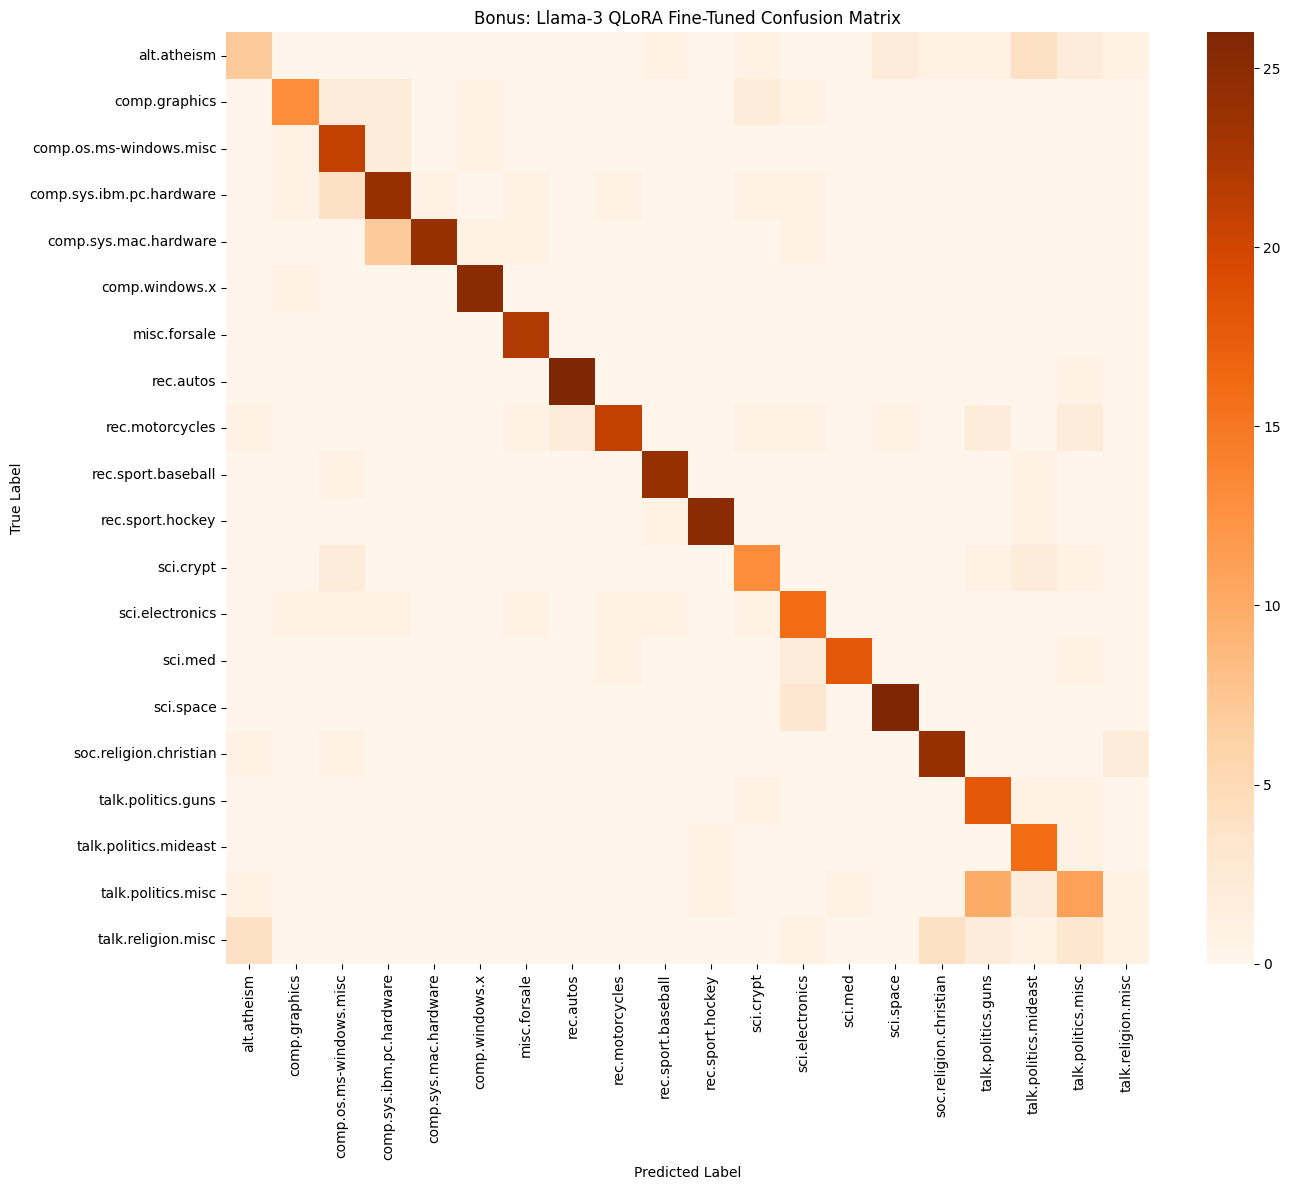

In [11]:
print(classification_report(y_true, y_pred, labels=list(id2label.keys()), target_names=label_names, zero_division=0))

valid_df = predictions_df[predictions_df["pred_label_id"] != -1]
cm = confusion_matrix(valid_df["true_label_id"], valid_df["pred_label_id"], labels=list(id2label.keys()))
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Oranges", annot=False, xticklabels=label_names, yticklabels=label_names)
plt.title("Bonus: Llama-3 QLoRA Fine-Tuned Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bonus_llama3_qlora_confusion_matrix.png", dpi=200)
plt.show()

## Compare with Previous Llama Zero-Shot and Few-Shot Results

This cell tries to load the Task 4 CSVs from `nlp_tasks_3_and_4.ipynb` and compare them with the fine-tuned QLoRA result.

In [15]:
def metrics_from_prediction_csv(path, model_name):
    df = pd.read_csv(path)
    y_true_local = df["true_label_id"].to_numpy()
    y_pred_local = df["pred_label_id"].to_numpy()
    acc = accuracy_score(y_true_local, y_pred_local)
    prec, rec, f1_local, _ = precision_recall_fscore_support(y_true_local, y_pred_local, average="weighted", zero_division=0)
    return {
        "Model": model_name,
        "Evaluation Samples": len(df),
        "Test Accuracy (%)": round(acc * 100, 2),
        "Test Precision": round(prec, 4),
        "Test Recall": round(rec, 4),
        "Test F1": round(f1_local, 4),
        "Unparsed Rate": round((df["pred_label_id"] == -1).mean(), 4),
        "Train Samples": 0,
        "Base Model": BASE_MODEL_NAME,
    }

comparison_rows = []
zero_path = Path("outputs/task4_llama3_zero_shot_predictions.csv")
few_path = Path("outputs/task4_llama3_few_shot_predictions.csv")

if zero_path.exists():
    comparison_rows.append(metrics_from_prediction_csv(zero_path, "Llama-3 zero-shot"))
else:
    print("Missing", zero_path)

if few_path.exists():
    comparison_rows.append(metrics_from_prediction_csv(few_path, "Llama-3 few-shot"))
else:
    print("Missing", few_path)

comparison_rows.extend(results_df.to_dict("records"))
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(OUTPUT_DIR / "bonus_llama3_comparison.csv", index=False)
comparison_df

,Model,Evaluation Samples,Test Accuracy (%),Test Precision,Test Recall,Test F1,Unparsed Rate,Train Samples,Base Model
0,Llama-3 zero-shot,2000,34.20,0.5101,0.3420,0.3147,0.000,0,meta-llama/Meta-Llama-3-8B-Instruct
1,Llama-3 few-shot,2000,31.75,0.4212,0.3175,0.2814,0.000,0,meta-llama/Meta-Llama-3-8B-Instruct
2,Llama-3 QLoRA fine-tuned,500,75.00,0.7546,0.7500,0.7434,0.006,2000,meta-llama/Meta-Llama-3-8B-Instruct


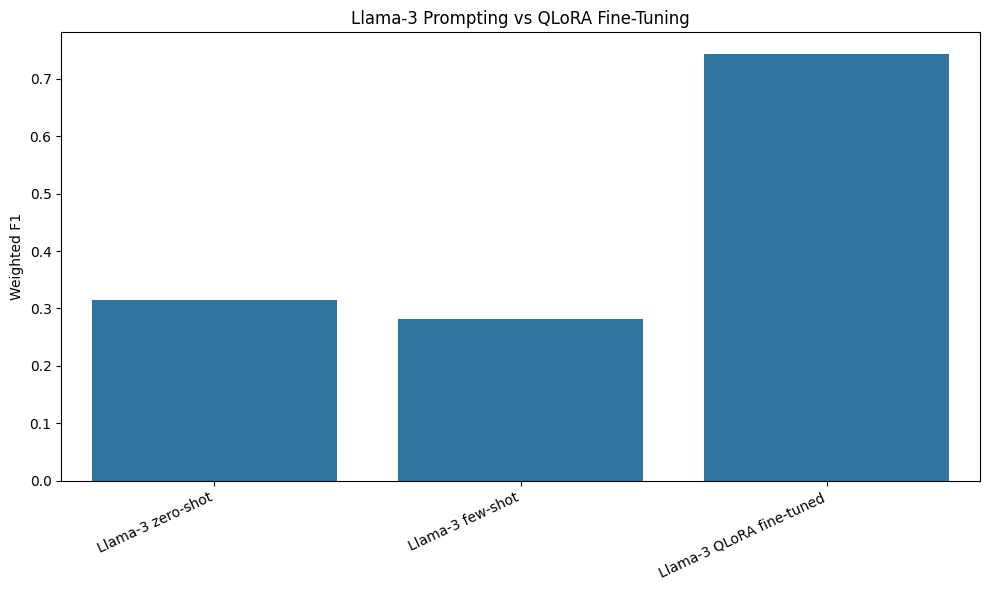

In [16]:
if len(comparison_df) > 1:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=comparison_df, x="Model", y="Test F1")
    plt.title("Llama-3 Prompting vs QLoRA Fine-Tuning")
    plt.ylabel("Weighted F1")
    plt.xlabel("")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "bonus_llama3_comparison_f1.png", dpi=200)
    plt.show()
else:
    print("Run zero-shot/few-shot first if you want an automatic comparison chart.")

# Saving Output Files to Drive

In [17]:
import os
import shutil

drive_output_dir = "/content/drive/MyDrive/NALAPRO_Final_Project/outputs"
os.makedirs(drive_output_dir, exist_ok=True)

bonus_files_to_copy = [
    "bonus_llama3_qlora_outputs/bonus_llama3_qlora_results.csv",
    "bonus_llama3_qlora_outputs/bonus_llama3_qlora_predictions.csv",
    "bonus_llama3_qlora_outputs/bonus_llama3_qlora_confusion_matrix.png",
    "bonus_llama3_qlora_outputs/bonus_llama3_comparison.csv",
    "bonus_llama3_qlora_outputs/bonus_llama3_comparison_f1.png",
]

for file in bonus_files_to_copy:
    if os.path.exists(file):
        shutil.copy(file, drive_output_dir)
        print("Copied:", file)
    else:
        print("Missing:", file)

Copied: bonus_llama3_qlora_outputs/bonus_llama3_qlora_results.csv
Copied: bonus_llama3_qlora_outputs/bonus_llama3_qlora_predictions.csv
Copied: bonus_llama3_qlora_outputs/bonus_llama3_qlora_confusion_matrix.png
Copied: bonus_llama3_qlora_outputs/bonus_llama3_comparison.csv
Copied: bonus_llama3_qlora_outputs/bonus_llama3_comparison_f1.png
